# 03 — Risk Segmentation

In this notebook we measure default risk across the segments created in Notebook 02:
- income_segment
- percent_income_segment
- loan_amount_segment

The goal is to identify which segments are high-risk, medium-risk, and low-risk, and to build clear risk profiles.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/credit_risk_dataset.csv")

# Income segments
income_bins = [0, 40000, 80000, df["person_income"].max()]
income_labels = ["Low", "Medium", "High"]

df["income_segment"] = pd.cut(
    df["person_income"],
    bins=income_bins,
    labels=income_labels,
    include_lowest=True
)

# Percent income segments
pi_bins = [0, 0.1, 0.3, df["loan_percent_income"].max()]
pi_labels = ["Low stress", "Medium stress", "High stress"]

df["percent_income_segment"] = pd.cut(
    df["loan_percent_income"],
    bins=pi_bins,
    labels=pi_labels,
    include_lowest=True
)

# Loan amount segments
la_bins = [0, 5000, 15000, df["loan_amnt"].max()]
la_labels = ["Small", "Medium", "Large"]

df["loan_amount_segment"] = pd.cut(
    df["loan_amnt"],
    bins=la_bins,
    labels=la_labels,
    include_lowest=True
)

Segments are recreated for this notebook. Code is copied from and identical to section 2.3. 

In [4]:
income_risk = (
    df.groupby("income_segment")["loan_status"]
    .mean()  # loan_status = 1 → default, so mean = default rate
    .rename("default_rate")
    .reset_index()
)

income_risk

,income_segment,default_rate
0,Low,0.376913
1,Medium,0.184757
2,High,0.093987


### Default rate by income segment

This table shows the default rate (loan_status = 1) for each income_segment.

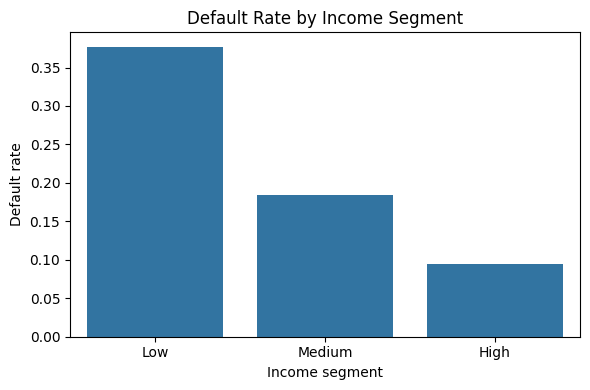

In [6]:
plt.figure(figsize=(6, 4))
sns.barplot(data=income_risk, x="income_segment", y="default_rate")
plt.title("Default Rate by Income Segment")
plt.ylabel("Default rate")
plt.xlabel("Income segment")
plt.tight_layout()
plt.show()

This barplot makes it easy to compare default risk across income segments.

In [7]:
pi_risk = (
    df.groupby("percent_income_segment")["loan_status"]
    .mean()
    .rename("default_rate")
    .reset_index()
)

pi_risk

,percent_income_segment,default_rate
0,Low stress,0.117226
1,Medium stress,0.174287
2,High stress,0.703182


### Default rate by percent income segment

This table shows how default risk changes with financial stress (percent_income_segment).

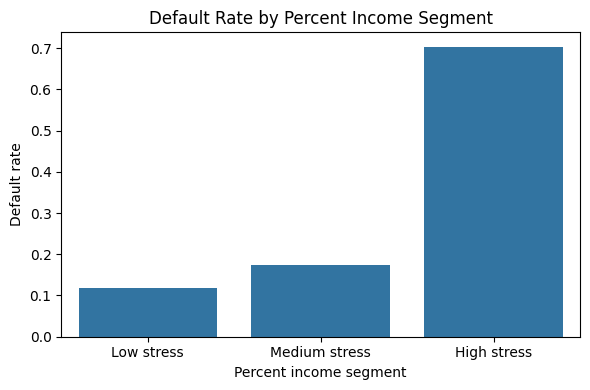

In [8]:
plt.figure(figsize=(6, 4))
sns.barplot(data=pi_risk, x="percent_income_segment", y="default_rate")
plt.title("Default Rate by Percent Income Segment")
plt.ylabel("Default rate")
plt.xlabel("Percent income segment")
plt.tight_layout()
plt.show()

Higher stress segments are expected to show higher default rates.

In [10]:
la_risk = (
    df.groupby("loan_amount_segment")["loan_status"]
    .mean()
    .rename("default_rate")
    .reset_index()
)

la_risk

,loan_amount_segment,default_rate
0,Small,0.204553
1,Medium,0.196719
2,Large,0.323392


### Default rate by loan amount segment

This table shows how default risk varies with loan size.

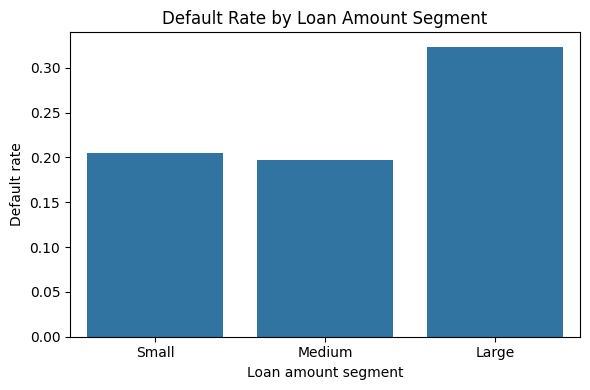

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(data=la_risk, x="loan_amount_segment", y="default_rate")
plt.title("Default Rate by Loan Amount Segment")
plt.ylabel("Default rate")
plt.xlabel("Loan amount segment")
plt.tight_layout()
plt.show()

This plot highlights whether larger loans are systematically riskier.

In [14]:
risk_matrix = pd.crosstab(
    df["percent_income_segment"],
    df["loan_amount_segment"],
    df["loan_status"],
    aggfunc="mean"
).round(3)

risk_matrix

loan_amount_segment,Small,Medium,Large
percent_income_segment,,,
Low stress,0.138,0.081,0.107
Medium stress,0.332,0.141,0.170
High stress,1.000,0.746,0.630


### Default rate matrix (percent income × loan amount)

This cross-tab shows default rates for combinations of stress level and loan size.
It helps identify high-risk combinations such as "High stress + Large loan".

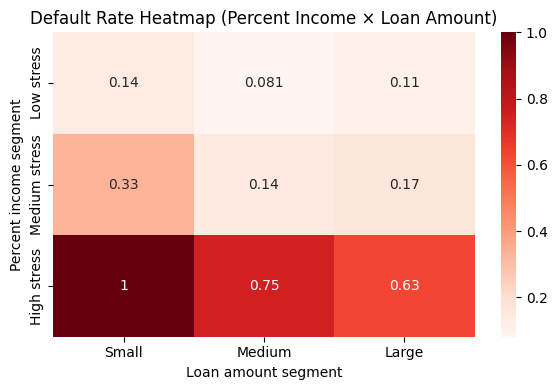

In [15]:
plt.figure(figsize=(6, 4))
sns.heatmap(risk_matrix, annot=True, cmap="Reds")
plt.title("Default Rate Heatmap (Percent Income × Loan Amount)")
plt.ylabel("Percent income segment")
plt.xlabel("Loan amount segment")
plt.tight_layout()
plt.show()

The heatmap visualizes which segment combinations are the riskiest.
Darker cells indicate higher default rates.

### Summary of Section 03

- Income segments show how default risk changes with income level.
- Percent income segments clearly separate low, medium, and high stress customers.
- Loan amount segments reveal how loan size contributes to risk.
- The combined matrix (percent income × loan amount) identifies the highest-risk segment combinations.

We now have clear risk profiles for:
- income_segment
- percent_income_segment
- loan_amount_segment
and for their combinations.

These profiles will be used in the risk report (Section 04) and to motivate the baseline ML model in Section 05.